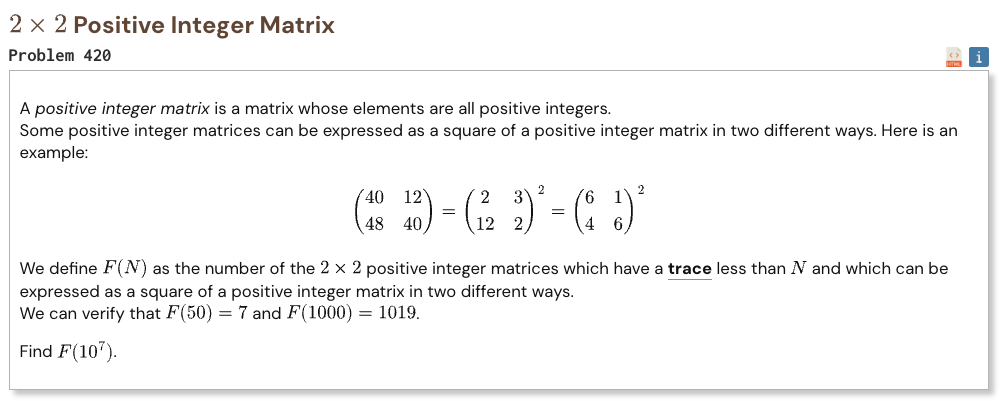

## Initial approach

-   write both square roots using four positive integers and compare the entries after squaring
-   the comparison shows that the two roots must have the same sum on their diagonal
-   reduce the problem to two numbers that control the possible diagonal values
-   only pairs whose squared values keep the final matrix trace below the limit need to be checked
-   use gcd to find how many different positive integer choices can produce the same squared matrix
-   count only cases where there are at least two valid square roots
-   loop only up to the square root of the trace limit instead of checking every possible matrix

In [1]:
from math import gcd, isqrt


def divisor_count_sieve(limit):
    divisors = [0] * (limit + 1)

    for i in range(1, limit + 1):
        for j in range(i, limit + 1, i):
            divisors[j] += 1

    return divisors


def solve(limit):
    max_value = isqrt(limit)
    divisors = divisor_count_sieve(2 * max_value)

    result = 0

    for u in range(2, max_value + 1):
        remaining = limit - 1 - u * u

        if remaining < 1:
            break

        max_v = min(u - 1, isqrt(remaining))

        for v in range(1, max_v + 1):
            g = gcd(u, v)

            reduced_u = u // g
            reduced_v = v // g

            if reduced_u % 2 == 1 and reduced_v % 2 == 1:
                k = 2 * g
            else:
                k = g

            if k < 2:
                continue

            total = u + v

            low = v * k // total + 1
            high = (u * k - 1) // total

            low = max(low, 1)
            high = min(high, k - 1)

            for a in range(low, high + 1):
                if gcd(a, k) == 1:
                    result += divisors[gcd(a * (k - a), k)]

    return result

In [2]:
%%time
result = solve(10**7)
print("Result:", result)

Result: 5561169
CPU times: user 1.75 s, sys: 10.8 ms, total: 1.76 s
Wall time: 1.76 s
